# Task 2: NES Multi-track Conditioned Generation

**Goal:** Given the NES Pulse 1 melody track (`P1`), generate a compatible Triangle bass track (`TR`).

This notebook is written to match the official NES-MDB MIDI example style where possible:
- Read MIDI files directly from `nesmdb_midi/train`, `nesmdb_midi/valid`, and `nesmdb_midi/test`
- Inspect each MIDI file with `pretty_midi`
- Treat the four NES voices as `P1`, `P2`, `TR`, and `NO`
- Train a small Seq2Seq LSTM baseline for melody-to-bass generation

Our folder structure:

```text
task2.ipynb
nesmdb_midi/
    train/
    valid/
    test/
```

In [1]:
# The following Python libraries were used:
# !pip install pretty_midi torch numpy matplotlib tqdm pandas

In [2]:
import os
import glob
import math
import copy
import random
import shutil
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
def seed_everything(seed=253):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(253)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Data loading

This section follows the official example style: use `glob` to collect MIDI files, then inspect tracks using `pretty_midi`.

In [4]:
archive_path = Path("nesmdb_midi.tar.gz")
dataset_dir = Path("nesmdb_midi")

if (not dataset_dir.exists()) and archive_path.exists():
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=Path("."))
    print("Extracted:", archive_path)
else:
    print("Dataset folder already exists or archive not found.")

Dataset folder already exists or archive not found.


In [5]:
DATASET_DIR = Path("nesmdb_midi")

train_files = sorted(glob.glob(str(DATASET_DIR / "train" / "*.mid")))
valid_files = sorted(glob.glob(str(DATASET_DIR / "valid" / "*.mid")))
test_files  = sorted(glob.glob(str(DATASET_DIR / "test"  / "*.mid")))

print("Train:", len(train_files))
print("Valid:", len(valid_files))
print("Test :", len(test_files))

print("\nFirst 5 train files:")
for f in train_files[:5]:
    print(f)

assert len(train_files) > 0, "No train MIDI files found. Check that nesmdb_midi/train exists."
assert len(valid_files) > 0, "No valid MIDI files found. Check that nesmdb_midi/valid exists."

Train: 4502
Valid: 403
Test : 373

First 5 train files:
nesmdb_midi\train\000_10_YardFight_00_01GameStart.mid
nesmdb_midi\train\000_10_YardFight_01_02GameOver.mid
nesmdb_midi\train\001_1942_00_01Start.mid
nesmdb_midi\train\001_1942_01_02MainBGM.mid
nesmdb_midi\train\001_1942_02_03Restart.mid


In [6]:
# Based on the official example: pick a random file and try reading it
mid_fp = random.choice(train_files)

print("Random MIDI file:")
print(mid_fp)

with open(mid_fp, "rb") as f:
    mid_bytes = f.read()

print("MIDI bytes:", len(mid_bytes))

Random MIDI file:
nesmdb_midi\train\397_YsII_AncientYsVanishedTheFinalChapter_13_14InsideofTheIceWall.mid
MIDI bytes: 2772


In [7]:
def inspect_midi_voices(mid_fp):
    midi_data = pretty_midi.PrettyMIDI(mid_fp)

    print("File:", mid_fp)
    print("Number of instruments:", len(midi_data.instruments))
    try:
        print("Estimated tempo:", midi_data.estimate_tempo())
    except Exception:
        print("Estimated tempo: unavailable")

    for i, instrument in enumerate(midi_data.instruments):
        print("-" * 80)
        print("Index:", i)
        print("Name:", instrument.name.upper())
        print("Program:", instrument.program)
        print("Is drum:", instrument.is_drum)

        notes = instrument.notes
        ccs = instrument.control_changes

        velocity_ccs = [cc for cc in ccs if cc.number == 11]
        timbre_ccs = [cc for cc in ccs if cc.number == 12]

        print("Number of notes:", len(notes))
        print("Number of velocity events:", len(velocity_ccs))
        print("Number of timbre events:", len(timbre_ccs))

        if len(notes) > 0:
            pitches = [n.pitch for n in notes]
            print("Pitch range:", min(pitches), "to", max(pitches))
            print("First 5 notes:")
            for n in notes[:5]:
                print(
                    "  pitch=", n.pitch,
                    "start=", round(n.start, 3),
                    "end=", round(n.end, 3),
                    "velocity=", n.velocity,
                )

    return midi_data

midi_data = inspect_midi_voices(mid_fp)

File: nesmdb_midi\train\397_YsII_AncientYsVanishedTheFinalChapter_13_14InsideofTheIceWall.mid
Number of instruments: 3
Estimated tempo: 282.8856378239775
--------------------------------------------------------------------------------
Index: 0
Name: P1
Program: 80
Is drum: False
Number of notes: 30
Number of velocity events: 164
Number of timbre events: 1
Pitch range: 57 to 77
First 5 notes:
  pitch= 64 start= 0.284 end= 0.717 velocity= 6
  pitch= 57 start= 0.717 end= 0.717 velocity= 1
  pitch= 69 start= 0.717 end= 1.153 velocity= 1
  pitch= 76 start= 1.153 end= 1.583 velocity= 1
  pitch= 69 start= 1.583 end= 2.016 velocity= 1
--------------------------------------------------------------------------------
Index: 1
Name: P2
Program: 81
Is drum: False
Number of notes: 31
Number of velocity events: 175
Number of timbre events: 1
Pitch range: 57 to 77
First 5 notes:
  pitch= 64 start= 0.068 end= 0.5 velocity= 8
  pitch= 57 start= 0.5 end= 0.5 velocity= 3
  pitch= 69 start= 0.5 end= 0.937 

## 2. Voice extraction

NES-MDB MIDI files normally use four main voices:
- `0`: `P1` / Pulse 1
- `1`: `P2` / Pulse 2
- `2`: `TR` / Triangle
- `3`: `NO` / Noise

For this project:
- condition input = `P1` melody
- generation target = `TR` bass

In [8]:
def safe_estimate_tempo(pm, default=120.0):
    try:
        tempo = float(pm.estimate_tempo())
        if np.isfinite(tempo) and 20 <= tempo <= 300:
            return tempo
    except Exception:
        pass
    return default


def load_nes_voices(mid_fp):
    '''
    Load a NES-MDB MIDI file and return the main NES voices.

    Expected order:
        0: P1 / Pulse 1
        1: P2 / Pulse 2
        2: TR / Triangle
        3: NO / Noise

    Returns a dictionary or None if the file is not usable.
    '''
    try:
        pm = pretty_midi.PrettyMIDI(mid_fp)
    except Exception:
        return None

    if len(pm.instruments) < 3:
        return None

    voices = {
        "pm": pm,
        "p1": pm.instruments[0],
        "p2": pm.instruments[1] if len(pm.instruments) > 1 else None,
        "tr": pm.instruments[2],
        "no": pm.instruments[3] if len(pm.instruments) > 3 else None,
        "tempo": safe_estimate_tempo(pm),
        "path": mid_fp,
    }

    # We need both melody and target bass to exist.
    if len(voices["p1"].notes) == 0 or len(voices["tr"].notes) == 0:
        return None

    return voices


def load_nes_tracks(mid_fp):
    '''
    Compatibility wrapper used by later code.
    Returns:
        pm, p1, tr, tempo
    '''
    voices = load_nes_voices(mid_fp)
    if voices is None:
        return None, None, None, None
    return voices["pm"], voices["p1"], voices["tr"], voices["tempo"]

In [9]:
voices = load_nes_voices(mid_fp)

if voices is None:
    print("Could not load voices from:", mid_fp)
else:
    print("Loaded:", voices["path"])
    print("Tempo:", voices["tempo"])
    print("P1 notes:", len(voices["p1"].notes))
    print("TR notes:", len(voices["tr"].notes))
    print("P2 notes:", len(voices["p2"].notes) if voices["p2"] else None)
    print("NO notes:", len(voices["no"].notes) if voices["no"] else None)

Loaded: nesmdb_midi\train\397_YsII_AncientYsVanishedTheFinalChapter_13_14InsideofTheIceWall.mid
Tempo: 282.8856378239775
P1 notes: 30
TR notes: 105
P2 notes: 31
NO notes: None


## 3. Tokenization

We use a simple event-duration token format:

```text
[event, duration, event, duration, ...]
```

Event tokens are either pitch tokens or `REST`. Duration tokens are quantized beat lengths. Including `REST` matters because otherwise the generated bass line could become too dense.

In [10]:
PAD = 0
BOS = 1
EOS = 2
REST = 3
SEP = 108

MIN_PITCH = 21
MAX_PITCH = 108
PITCH_OFFSET = 4

DURATION_BINS = np.array([
    0.125, 0.25, 0.375, 0.5,
    0.625, 0.75, 1.0, 1.25,
    1.5, 1.75, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5,
], dtype=float)

DUR_OFFSET = 92
VOCAB_SIZE = 109

PITCH_TOKEN_MIN = PITCH_OFFSET
PITCH_TOKEN_MAX = PITCH_OFFSET + (MAX_PITCH - MIN_PITCH)

DUR_TOKEN_MIN = DUR_OFFSET
DUR_TOKEN_MAX = DUR_OFFSET + len(DURATION_BINS) - 1

EVENT_TOKENS = list(range(PITCH_TOKEN_MIN, PITCH_TOKEN_MAX + 1)) + [REST, EOS]
DURATION_TOKENS = list(range(DUR_TOKEN_MIN, DUR_TOKEN_MAX + 1))

print("Pitch tokens:", PITCH_TOKEN_MIN, "to", PITCH_TOKEN_MAX)
print("Duration tokens:", DUR_TOKEN_MIN, "to", DUR_TOKEN_MAX)
print("Vocab size:", VOCAB_SIZE)

Pitch tokens: 4 to 91
Duration tokens: 92 to 107
Vocab size: 109


In [11]:
def quantize_duration_seconds(duration_sec, tempo=120.0):
    '''
    Convert duration in seconds to nearest duration token.
    DURATION_BINS are measured in beats.
    '''
    duration_sec = max(float(duration_sec), 1e-4)
    duration_beats = duration_sec * tempo / 60.0
    idx = int(np.argmin(np.abs(DURATION_BINS - duration_beats)))
    return DUR_OFFSET + idx


def duration_token_to_seconds(duration_token, tempo=120.0):
    idx = int(duration_token - DUR_OFFSET)
    idx = max(0, min(idx, len(DURATION_BINS) - 1))
    duration_beats = DURATION_BINS[idx]
    return float(duration_beats * 60.0 / tempo)


def pitch_to_token(pitch):
    pitch = int(pitch)
    if pitch < MIN_PITCH or pitch > MAX_PITCH:
        return None
    return pitch - MIN_PITCH + PITCH_OFFSET


def token_to_pitch(token):
    return int(token - PITCH_OFFSET + MIN_PITCH)


def track_to_tokens(instrument, tempo=120.0, add_rests=True, min_gap_sec=0.03):
    '''
    Convert a MIDI instrument track to:
        [event, duration, event, duration, ...]

    event is either a pitch token or REST.
    '''
    tokens = []
    notes = sorted(instrument.notes, key=lambda n: (n.start, n.pitch, n.end))

    current_time = 0.0

    for note in notes:
        # Add REST token if there is a gap before this note.
        if add_rests and note.start > current_time + min_gap_sec:
            gap = note.start - current_time
            tokens.append(REST)
            tokens.append(quantize_duration_seconds(gap, tempo))

        pitch_tok = pitch_to_token(note.pitch)
        dur_tok = quantize_duration_seconds(note.end - note.start, tempo)

        if pitch_tok is not None:
            tokens.append(pitch_tok)
            tokens.append(dur_tok)

        current_time = max(current_time, note.end)

    return tokens

In [12]:
pm, p1, tr, tempo = load_nes_tracks(mid_fp)

p1_tokens = track_to_tokens(p1, tempo, add_rests=True)
tr_tokens = track_to_tokens(tr, tempo, add_rests=True)

print("P1 token length:", len(p1_tokens))
print("TR token length:", len(tr_tokens))
print("P1 first 20:", p1_tokens[:20])
print("TR first 20:", tr_tokens[:20])

P1 token length: 68
TR token length: 308
P1 first 20: [3, 99, 47, 102, 40, 92, 52, 102, 59, 102, 52, 102, 50, 102, 53, 102, 57, 102, 3, 102]
TR first 20: [3, 93, 11, 92, 10, 92, 23, 98, 3, 98, 11, 92, 23, 96, 3, 94, 11, 92, 23, 96]


In [13]:
def decode_token_pairs(tokens, n_pairs=10):
    pairs = []
    for i in range(0, min(len(tokens), n_pairs * 2), 2):
        event_tok = tokens[i]
        dur_tok = tokens[i + 1] if i + 1 < len(tokens) else None

        if event_tok == REST:
            event = "REST"
        elif PITCH_TOKEN_MIN <= event_tok <= PITCH_TOKEN_MAX:
            pitch = token_to_pitch(event_tok)
            event = f"PITCH_{pitch}"
        elif event_tok == EOS:
            event = "EOS"
        else:
            event = f"UNKNOWN_{event_tok}"

        if dur_tok is not None and DUR_TOKEN_MIN <= dur_tok <= DUR_TOKEN_MAX:
            dur_idx = dur_tok - DUR_OFFSET
            dur_beats = DURATION_BINS[dur_idx]
            dur = f"{dur_beats} beats"
        else:
            dur = f"UNKNOWN_DUR_{dur_tok}"

        pairs.append((event, dur))

    return pairs

In [14]:
print(decode_token_pairs(p1_tokens, n_pairs=10))
print(decode_token_pairs(tr_tokens, n_pairs=10))

[('REST', '1.25 beats'), ('PITCH_64', '2.0 beats'), ('PITCH_57', '0.125 beats'), ('PITCH_69', '2.0 beats'), ('PITCH_76', '2.0 beats'), ('PITCH_69', '2.0 beats'), ('PITCH_67', '2.0 beats'), ('PITCH_70', '2.0 beats'), ('PITCH_74', '2.0 beats'), ('REST', '2.0 beats')]
[('REST', '0.25 beats'), ('PITCH_28', '0.125 beats'), ('PITCH_27', '0.125 beats'), ('PITCH_40', '1.0 beats'), ('REST', '1.0 beats'), ('PITCH_28', '0.125 beats'), ('PITCH_40', '0.625 beats'), ('REST', '0.375 beats'), ('PITCH_28', '0.125 beats'), ('PITCH_40', '0.625 beats')]


## 4. Dataset and DataLoader

In [15]:
class NESPairDataset(Dataset):
    def __init__(
        self,
        file_paths,
        max_p1=192,
        max_tr=192,
        add_rests=True,
        min_p1_notes=5,
        min_tr_notes=3,
        max_files=None,
    ):
        self.samples = []
        self.skipped = 0

        if max_files is not None:
            file_paths = file_paths[:max_files]

        for path in tqdm(file_paths, desc="Building NESPairDataset"):
            pm, p1, tr, tempo = load_nes_tracks(path)

            if p1 is None or tr is None:
                self.skipped += 1
                continue

            if len(p1.notes) < min_p1_notes or len(tr.notes) < min_tr_notes:
                self.skipped += 1
                continue

            p1_tok = track_to_tokens(p1, tempo, add_rests=add_rests)
            tr_tok = track_to_tokens(tr, tempo, add_rests=add_rests)

            if len(p1_tok) < 4 or len(tr_tok) < 4:
                self.skipped += 1
                continue

            # Encoder input: BOS + P1 melody tokens + EOS
            p1_seq = [BOS] + p1_tok[:max_p1] + [EOS]

            # Decoder sequence: BOS + TR bass tokens + EOS
            # decoder input  = tr_seq[:-1]
            # decoder target = tr_seq[1:]
            tr_seq = [BOS] + tr_tok[:max_tr] + [EOS]

            self.samples.append({
                "p1": p1_seq,
                "tr": tr_seq,
                "path": path,
                "tempo": tempo,
            })

        print(f"Loaded {len(self.samples)} samples. Skipped {self.skipped} files.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return item["p1"], item["tr"], item["path"], item["tempo"]


def collate_nes_pairs(batch):
    p1_batch, tr_batch, paths, tempos = zip(*batch)

    p1_lens = torch.tensor([len(x) for x in p1_batch], dtype=torch.long)
    tr_lens = torch.tensor([len(x) for x in tr_batch], dtype=torch.long)

    max_p1_len = int(max(p1_lens).item())
    max_tr_len = int(max(tr_lens).item())

    p1_padded = torch.full((len(batch), max_p1_len), PAD, dtype=torch.long)
    tr_padded = torch.full((len(batch), max_tr_len), PAD, dtype=torch.long)

    for i, seq in enumerate(p1_batch):
        p1_padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)

    for i, seq in enumerate(tr_batch):
        tr_padded[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)

    tempos = torch.tensor(tempos, dtype=torch.float32)

    return p1_padded, tr_padded, p1_lens, tr_lens, list(paths), tempos

In [16]:
# Small debug dataset first. Increase max_files or set to None after this works.
DEBUG_MAX_FILES = 300

train_ds_debug = NESPairDataset(train_files, max_files=DEBUG_MAX_FILES)
valid_ds_debug = NESPairDataset(valid_files, max_files=100)

train_loader_debug = DataLoader(
    train_ds_debug,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_nes_pairs,
)

valid_loader_debug = DataLoader(
    valid_ds_debug,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_nes_pairs,
)

batch = next(iter(train_loader_debug))
p1_batch, tr_batch, p1_lens, tr_lens, paths, tempos = batch

print("P1 batch:", p1_batch.shape)
print("TR batch:", tr_batch.shape)
print("P1 lengths:", p1_lens[:5])
print("TR lengths:", tr_lens[:5])
print("Example path:", paths[0])

Building NESPairDataset: 100%|██████████| 300/300 [00:07<00:00, 39.57it/s]


Loaded 239 samples. Skipped 61 files.


Building NESPairDataset: 100%|██████████| 100/100 [00:03<00:00, 33.21it/s]

Loaded 85 samples. Skipped 15 files.
P1 batch: torch.Size([32, 194])
TR batch: torch.Size([32, 194])
P1 lengths: tensor([ 38, 194, 194,  42, 194])
TR lengths: tensor([ 46, 194, 194,  44, 194])
Example path: nesmdb_midi\train\031_BioMiracleBokutteUpa_11_12Miss.mid


## 5. Seq2Seq LSTM model

The encoder reads `P1` melody tokens. The decoder generates `TR` bass tokens.

In [17]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

    def forward(self, src, src_lens):
        embedded = self.embedding(src)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lens.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, (h, c) = self.lstm(packed)

        # Last layer forward and backward hidden states.
        h_last = torch.cat([h[-2], h[-1]], dim=1)
        c_last = torch.cat([c[-2], c[-1]], dim=1)

        h_dec = torch.tanh(self.fc_h(h_last))
        c_dec = torch.tanh(self.fc_c(c_last))

        # Repeat for decoder layers.
        h_dec = h_dec.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c_dec = c_dec.unsqueeze(0).repeat(self.num_layers, 1, 1)

        return (h_dec, c_dec)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, hidden):
        # input_token: (batch, 1)
        embedded = self.embedding(input_token)
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(self.dropout(output.squeeze(1)))
        return logits, hidden


class Seq2SeqNES(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=128,
        hidden_dim=256,
        num_layers=1,
        dropout=0.2,
    ):
        super().__init__()

        self.encoder = Encoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

        self.decoder = Decoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

    def forward(self, src, src_lens, tgt_input, teacher_forcing_ratio=0.7):
        '''
        src:       (B, S)
        src_lens:  (B,)
        tgt_input: (B, T), usually TR sequence without final token

        returns:
            logits: (B, T, VOCAB_SIZE)
        '''
        batch_size, tgt_len = tgt_input.shape
        hidden = self.encoder(src, src_lens)

        outputs = torch.zeros(batch_size, tgt_len, VOCAB_SIZE, device=src.device)

        # First decoder input should be BOS.
        dec_input = tgt_input[:, 0:1]

        for t in range(tgt_len):
            logits, hidden = self.decoder(dec_input, hidden)
            outputs[:, t, :] = logits

            if t < tgt_len - 1:
                use_teacher = random.random() < teacher_forcing_ratio
                if use_teacher:
                    dec_input = tgt_input[:, t + 1:t + 2]
                else:
                    dec_input = logits.argmax(dim=1, keepdim=True)

        return outputs

In [18]:
model = Seq2SeqNES(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    dropout=0.2,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", n_params)

# Forward-pass smoke test
p1_batch = p1_batch.to(device)
tr_batch = tr_batch.to(device)
p1_lens = p1_lens.to(device)

tgt_input = tr_batch[:, :-1]
tgt_target = tr_batch[:, 1:]

logits = model(
    p1_batch,
    p1_lens,
    tgt_input,
    teacher_forcing_ratio=0.7,
)

print("Logits:", logits.shape)
print("Target:", tgt_target.shape)

Trainable parameters: 1504365
Logits: torch.Size([32, 193, 109])
Target: torch.Size([32, 193])


## 6. Training

In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)


def run_epoch(model, loader, optimizer=None, teacher_forcing_ratio=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_tokens = 0

    for p1, tr, p1_lens, tr_lens, paths, tempos in tqdm(loader, leave=False):
        p1 = p1.to(device)
        tr = tr.to(device)
        p1_lens = p1_lens.to(device)

        tgt_input = tr[:, :-1]
        tgt_target = tr[:, 1:]

        with torch.set_grad_enabled(is_train):
            logits = model(
                p1,
                p1_lens,
                tgt_input,
                teacher_forcing_ratio=teacher_forcing_ratio,
            )

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                tgt_target.reshape(-1),
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        n_tokens = (tgt_target != PAD).sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / max(1, total_tokens)
    ppl = math.exp(min(avg_loss, 20))

    return avg_loss, ppl


def train_model(
    model,
    train_loader,
    valid_loader,
    epochs=10,
    lr=5e-4,
    save_path="nes_seq2seq_best.pt",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    history = []

    for epoch in range(epochs):
        # Start with high teacher forcing, then reduce.
        teacher_ratio = max(0.35, 0.90 - epoch * 0.04)

        train_loss, train_ppl = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            teacher_forcing_ratio=teacher_ratio,
        )

        val_loss, val_ppl = run_epoch(
            model,
            valid_loader,
            optimizer=None,
            teacher_forcing_ratio=1.0,
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_ppl": train_ppl,
            "val_loss": val_loss,
            "val_ppl": val_ppl,
            "teacher_ratio": teacher_ratio,
        }
        history.append(row)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train loss={train_loss:.4f}, ppl={train_ppl:.2f} | "
            f"val loss={val_loss:.4f}, ppl={val_ppl:.2f} | "
            f"teacher={teacher_ratio:.2f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print("  saved best checkpoint")

    return pd.DataFrame(history)

In [20]:
# Quick debug training.
history_debug = train_model(
    model,
    train_loader_debug,
    valid_loader_debug,
    epochs=3,
    lr=5e-4,
    save_path="nes_seq2seq_debug_best.pt",
)

history_debug

Epoch 01 | train loss=4.5705, ppl=96.59 | val loss=4.3804, ppl=79.87 | teacher=0.90
  saved best checkpoint


Epoch 02 | train loss=3.9997, ppl=54.58 | val loss=3.4905, ppl=32.80 | teacher=0.86
  saved best checkpoint


Epoch 03 | train loss=3.2058, ppl=24.67 | val loss=3.1414, ppl=23.14 | teacher=0.82
  saved best checkpoint


,epoch,train_loss,train_ppl,val_loss,val_ppl,teacher_ratio
0,1,4.570522,96.594556,4.380415,79.871180,0.90
1,2,3.999707,54.582139,3.490474,32.801497,0.86
2,3,3.205753,24.674079,3.141422,23.136749,0.82


### Optional: full training

After the debug run works, run the following cell. For a quick handoff, `epochs=10` is enough. For the final result, the teammate doing tuning can try `epochs=20` or `epochs=30`.

In [21]:
RUN_FULL_TRAINING = False  # Change to True when ready.

if RUN_FULL_TRAINING:
    train_ds = NESPairDataset(train_files, max_files=None)
    valid_ds = NESPairDataset(valid_files, max_files=None)

    train_loader = DataLoader(
        train_ds,
        batch_size=32,
        shuffle=True,
        collate_fn=collate_nes_pairs,
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=32,
        shuffle=False,
        collate_fn=collate_nes_pairs,
    )

    model = Seq2SeqNES(
        vocab_size=VOCAB_SIZE,
        embed_dim=128,
        hidden_dim=256,
        num_layers=1,
        dropout=0.2,
    ).to(device)

    history = train_model(
        model,
        train_loader,
        valid_loader,
        epochs=10,
        lr=5e-4,
        save_path="nes_seq2seq_best.pt",
    )

    display(history)

    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("NES Seq2Seq Training Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("nes_training_curve.png", dpi=150)
    plt.show()
else:
    print("Skipping full training. Set RUN_FULL_TRAINING = True when ready.")

Skipping full training. Set RUN_FULL_TRAINING = True when ready.


## 7. Constrained sampling

During generation, we constrain the model to produce legal token order:

```text
event, duration, event, duration, ...
```

Event positions allow pitch tokens, `REST`, and later `EOS`. Duration positions only allow duration tokens.

In [22]:
def sample_from_logits(logits, allowed_ids, temperature=0.9, top_k=0):
    '''
    logits: (VOCAB_SIZE,)
    allowed_ids: list[int]
    '''
    logits = logits.clone().detach()

    masked = torch.full_like(logits, float("-inf"))
    allowed = torch.tensor(allowed_ids, dtype=torch.long, device=logits.device)

    masked[allowed] = logits[allowed] / max(temperature, 1e-6)

    if top_k is not None and top_k > 0 and top_k < len(allowed_ids):
        top_vals, top_idx = torch.topk(masked, top_k)
        keep = torch.full_like(masked, float("-inf"))
        keep[top_idx] = masked[top_idx]
        masked = keep

    probs = F.softmax(masked, dim=-1)

    if torch.isnan(probs).any() or probs.sum().item() <= 0:
        return int(random.choice(allowed_ids))

    return int(torch.multinomial(probs, num_samples=1).item())


def generate_bass(
    model,
    p1_tokens,
    temperature=0.75,
    top_k=20,
    max_len=300,
    min_events_before_eos=40,
):
    model.eval()

    if len(p1_tokens) == 0 or p1_tokens[0] != BOS:
        p1_tokens = [BOS] + p1_tokens
    if p1_tokens[-1] != EOS:
        p1_tokens = p1_tokens + [EOS]

    src = torch.tensor([p1_tokens], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(p1_tokens)], dtype=torch.long, device=device)

    hidden = model.encoder(src, src_lens)

    dec_input = torch.tensor([[BOS]], dtype=torch.long, device=device)

    generated = []
    expecting_event = True
    event_count = 0

    with torch.no_grad():
        for _ in range(max_len):
            logits, hidden = model.decoder(dec_input, hidden)
            logits = logits.squeeze(0)

            if expecting_event:
                allowed = list(range(PITCH_TOKEN_MIN, PITCH_TOKEN_MAX + 1)) + [REST]

                if event_count >= min_events_before_eos:
                    allowed = allowed + [EOS]

                next_tok = sample_from_logits(
                    logits,
                    allowed,
                    temperature=temperature,
                    top_k=top_k,
                )

                if next_tok == EOS:
                    break

                generated.append(next_tok)
                event_count += 1
                expecting_event = False

            else:
                allowed = list(range(DUR_TOKEN_MIN, DUR_TOKEN_MAX + 1))

                next_tok = sample_from_logits(
                    logits,
                    allowed,
                    temperature=temperature,
                    top_k=min(top_k, len(allowed)) if top_k else 0,
                )

                generated.append(next_tok)
                expecting_event = True

            dec_input = torch.tensor([[next_tok]], dtype=torch.long, device=device)

    # Drop dangling event token if no duration follows it.
    if len(generated) % 2 == 1:
        generated = generated[:-1]

    return generated

## 8. Decode generated tokens back to MIDI

In [23]:
def tokens_to_midi_track(
    tokens,
    tempo=120.0,
    program=38,
    velocity=100,
    transpose=0,
    min_pitch=24,
    max_pitch=72,
    name="Generated Triangle Bass",
):
    '''
    Convert [event, duration, event, duration, ...] into a pretty_midi.Instrument.

    program=38 is Synth Bass 1 in General MIDI.
    program=33 is Acoustic Bass
    '''
    inst = pretty_midi.Instrument(program=program, is_drum=False, name=name)

    current_time = 0.0
    i = 0

    while i < len(tokens) - 1:
        event_tok = int(tokens[i])
        dur_tok = int(tokens[i + 1])

        if not (DUR_TOKEN_MIN <= dur_tok <= DUR_TOKEN_MAX):
            i += 2
            continue

        dur_sec = duration_token_to_seconds(dur_tok, tempo)

        if event_tok == REST:
            current_time += dur_sec

        elif PITCH_TOKEN_MIN <= event_tok <= PITCH_TOKEN_MAX:
            pitch = token_to_pitch(event_tok)
            pitch = pitch + transpose
            pitch = int(max(min_pitch, min(max_pitch, pitch)))

            note = pretty_midi.Note(
                velocity=velocity,
                pitch=pitch,
                start=current_time,
                end=current_time + dur_sec,
            )
            inst.notes.append(note)
            current_time += dur_sec

        elif event_tok == EOS:
            break

        i += 2

    return inst


def save_conditioned_generation(
    model,
    midi_path,
    output_path="symbolic_conditioned.mid",
    temperature=0.85,
    top_k=20,
    max_p1=192,
    max_gen_len=300,
    include_ground_truth=False,
):
    pm, p1, tr, tempo = load_nes_tracks(midi_path)

    if p1 is None:
        raise ValueError(f"Could not load P1/TR from {midi_path}")

    p1_tokens = [BOS] + track_to_tokens(p1, tempo, add_rests=True)[:max_p1] + [EOS]

    generated_tokens = generate_bass(
        model,
        p1_tokens,
        temperature=temperature,
        top_k=top_k,
        max_len=max_gen_len,
    )

    generated_tr = tokens_to_midi_track(
        generated_tokens,
        tempo=tempo,
        program=38,
        velocity=100,
        transpose=-12,
        name="Generated Triangle Bass",
    )

    out_pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)

    p1_copy = copy.deepcopy(p1)
    p1_copy.name = "Pulse 1 Melody"
    p1_copy.program = 80  # Lead 1 square-ish in General MIDI.

    out_pm.instruments.append(p1_copy)
    out_pm.instruments.append(generated_tr)

    if include_ground_truth:
        tr_copy = copy.deepcopy(tr)
        tr_copy.name = "Ground Truth Triangle Bass"
        tr_copy.program = 33
        out_pm.instruments.append(tr_copy)

    out_pm.write(output_path)

    print("Saved:", output_path)
    print("Source:", midi_path)
    print("Generated tokens:", len(generated_tokens))
    print("Generated notes:", len(generated_tr.notes))

    return {
        "pm": out_pm,
        "p1": p1_copy,
        "generated_tr": generated_tr,
        "ground_truth_tr": tr,
        "generated_tokens": generated_tokens,
        "tempo": tempo,
        "midi_path": midi_path,
    }

In [24]:
# Use full-training checkpoint if it exists; otherwise use debug checkpoint.
checkpoint_path = "nes_seq2seq_best.pt" if Path("nes_seq2seq_best.pt").exists() else "nes_seq2seq_debug_best.pt"

if Path(checkpoint_path).exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Loaded checkpoint:", checkpoint_path)
else:
    print("No checkpoint found. Using current model weights.")

model.to(device)

sample_test_file = test_files[0] if len(test_files) > 0 else valid_files[0]

gen_result = save_conditioned_generation(
    model,
    sample_test_file,
    output_path="symbolic_conditioned.mid",
    temperature=0.85,
    top_k=20,
    max_p1=192,
    max_gen_len=300,
    include_ground_truth=False,
)

comparison_result = save_conditioned_generation(
    model,
    sample_test_file,
    output_path="symbolic_conditioned_with_groundtruth.mid",
    temperature=0.85,
    top_k=20,
    max_p1=192,
    max_gen_len=300,
    include_ground_truth=True,
)

Loaded checkpoint: nes_seq2seq_debug_best.pt
Saved: symbolic_conditioned.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Generated tokens: 300
Generated notes: 38
Saved: symbolic_conditioned_with_groundtruth.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Generated tokens: 300
Generated notes: 42


In [25]:
test_ds = NESPairDataset(test_files, max_files=None)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_nes_pairs,
)

test_eval_loss, test_eval_ppl = run_epoch(
    model,
    test_loader,
    optimizer=None,
    teacher_forcing_ratio=1.0
)

print("Test loss:", test_eval_loss)
print("Test ppl:", test_eval_ppl)

Building NESPairDataset: 100%|██████████| 373/373 [00:07<00:00, 50.28it/s]


Loaded 246 samples. Skipped 127 files.


Test loss: 3.2250700675676973
Test ppl: 25.15533666732508


## 9. Piano-roll visualization

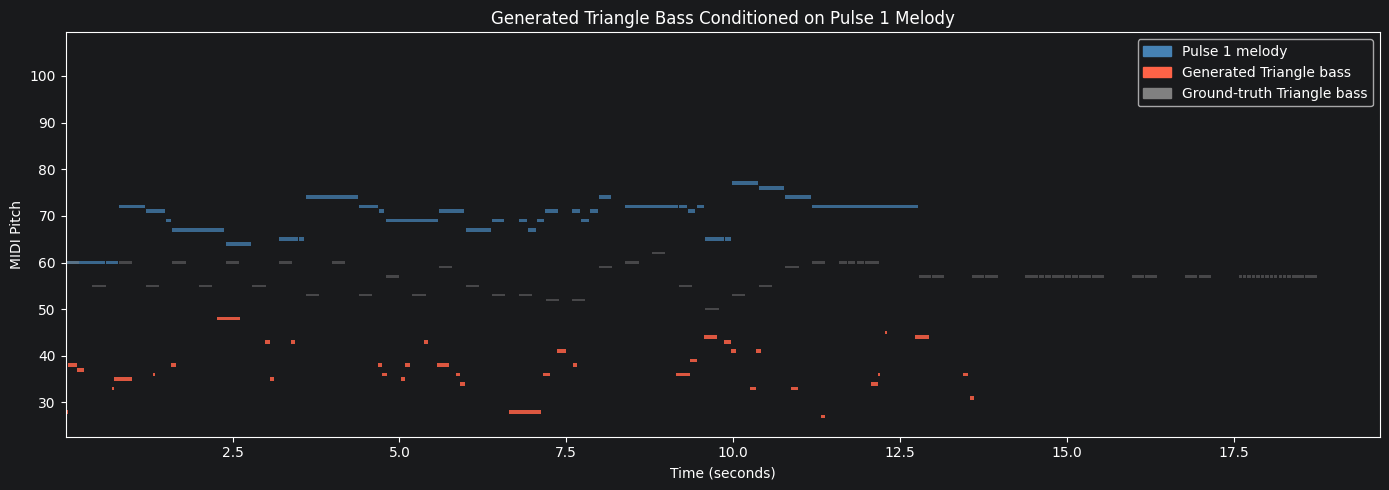

Saved figure: piano_roll_generated.png


In [26]:
def plot_piano_roll(
    p1_inst,
    generated_tr_inst,
    ground_truth_tr_inst=None,
    title="P1 Melody and Generated Triangle Bass",
    output_path="piano_roll_generated.png",
):
    fig, ax = plt.subplots(figsize=(14, 5))

    for note in p1_inst.notes:
        ax.barh(
            note.pitch,
            note.end - note.start,
            left=note.start,
            height=0.8,
            color="steelblue",
            alpha=0.75,
        )

    for note in generated_tr_inst.notes:
        ax.barh(
            note.pitch,
            note.end - note.start,
            left=note.start,
            height=0.8,
            color="tomato",
            alpha=0.85,
        )

    if ground_truth_tr_inst is not None:
        for note in ground_truth_tr_inst.notes:
            ax.barh(
                note.pitch,
                note.end - note.start,
                left=note.start,
                height=0.45,
                color="gray",
                alpha=0.45,
            )

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("MIDI Pitch")
    ax.set_title(title)

    patches = [
        mpatches.Patch(color="steelblue", label="Pulse 1 melody"),
        mpatches.Patch(color="tomato", label="Generated Triangle bass"),
    ]

    if ground_truth_tr_inst is not None:
        patches.append(mpatches.Patch(color="gray", label="Ground-truth Triangle bass"))

    ax.legend(handles=patches)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Saved figure:", output_path)


plot_piano_roll(
    gen_result["p1"],
    gen_result["generated_tr"],
    ground_truth_tr_inst=gen_result["ground_truth_tr"],
    title="Generated Triangle Bass Conditioned on Pulse 1 Melody",
    output_path="piano_roll_generated.png",
)

## 9.5 Evaluation metrics

Compute per-track statistics and compare feature distributions across test files.

In [ ]:
def summarize_generation(p1_inst, generated_tr_inst, ground_truth_tr_inst=None, time_grid=0.1):
    """
    Compute summary statistics for generated (and optionally ground-truth) TR tracks.

    Returns a DataFrame with columns:
        track, n_notes, mean_pitch, pitch_range, note_density,
        pc_compatibility_with_p1, onset_alignment_with_p1
    """
    def _stats(inst, label):
        notes = inst.notes
        if len(notes) == 0:
            return dict(track=label, n_notes=0, mean_pitch=float("nan"),
                        pitch_range=0, note_density=0.0,
                        pc_compatibility_with_p1=0.0, onset_alignment_with_p1=0.0)
        pitches = [n.pitch for n in notes]
        duration = max(n.end for n in notes) - min(n.start for n in notes)
        duration = max(duration, 1e-3)

        p1_pcs = set(n.pitch % 12 for n in p1_inst.notes)
        pc_compat = sum(1 for n in notes if n.pitch % 12 in p1_pcs) / len(notes)

        p1_onset_bins = set(round(n.start / time_grid) for n in p1_inst.notes)
        onset_align = sum(1 for n in notes if round(n.start / time_grid) in p1_onset_bins) / len(notes)

        return dict(
            track=label,
            n_notes=len(notes),
            mean_pitch=float(np.mean(pitches)),
            pitch_range=int(max(pitches) - min(pitches)),
            note_density=float(len(notes) / duration),
            pc_compatibility_with_p1=float(pc_compat),
            onset_alignment_with_p1=float(onset_align),
        )

    rows = [_stats(generated_tr_inst, "Generated TR bass")]
    if ground_truth_tr_inst is not None:
        rows.append(_stats(ground_truth_tr_inst, "Ground Truth TR bass"))
    return pd.DataFrame(rows)


def plot_feature_distribution(
    generated_tr_list,
    ground_truth_tr_list,
    p1_list,
    output_path="feature_distribution.png",
):
    """
    Plot histograms comparing note density and pitch distribution of generated
    vs ground-truth TR tracks across a list of test examples.
    """
    gen_densities, gt_densities = [], []
    gen_pitches, gt_pitches = [], []

    for p1_inst, gen_inst, gt_inst in zip(p1_list, generated_tr_list, ground_truth_tr_list):
        if len(gen_inst.notes) == 0 or len(gt_inst.notes) == 0:
            continue
        gen_df = summarize_generation(p1_inst, gen_inst, gt_inst)
        gen_row = gen_df[gen_df["track"] == "Generated TR bass"].iloc[0]
        gt_row  = gen_df[gen_df["track"] == "Ground Truth TR bass"].iloc[0]

        gen_densities.append(gen_row["note_density"])
        gt_densities.append(gt_row["note_density"])
        gen_pitches.extend([n.pitch for n in gen_inst.notes])
        gt_pitches.extend([n.pitch for n in gt_inst.notes])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(gt_densities,  bins=20, alpha=0.65, color="steelblue", label="Ground Truth TR")
    axes[0].hist(gen_densities, bins=20, alpha=0.65, color="tomato",    label="Generated TR")
    axes[0].set_xlabel("Note density (notes / second)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Note Density Distribution")
    axes[0].legend()

    pitch_bins = range(21, 109)
    axes[1].hist(gt_pitches,  bins=pitch_bins, alpha=0.65, color="steelblue", label="Ground Truth TR")
    axes[1].hist(gen_pitches, bins=pitch_bins, alpha=0.65, color="tomato",    label="Generated TR")
    axes[1].set_xlabel("MIDI Pitch")
    axes[1].set_ylabel("Note count")
    axes[1].set_title("Pitch Distribution")
    axes[1].legend()

    plt.suptitle("Generated vs Ground-Truth TR Bass: Feature Distributions")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    print("Saved figure:", output_path)


In [ ]:
metrics_df = summarize_generation(
    gen_result["p1"],
    gen_result["generated_tr"],
    gen_result["ground_truth_tr"],
)
print("Single-example metrics:")
display(metrics_df)


In [ ]:
# Build lists of (p1, generated_tr, ground_truth_tr) from test_files for the plot.
_p1_list, _gen_list, _gt_list = [], [], []

for _fp in test_files[:60]:
    try:
        _r = save_conditioned_generation(
            model, _fp,
            output_path=f"/tmp/_eval_candidate.mid",
            temperature=0.75, top_k=20, max_p1=192, max_gen_len=300,
            include_ground_truth=False,
        )
        _p1_list.append(_r["p1"])
        _gen_list.append(_r["generated_tr"])
        _gt_list.append(_r["ground_truth_tr"])
    except Exception as _e:
        pass

print(f"Collected {len(_p1_list)} examples for feature distribution plot.")

plot_feature_distribution(
    _gen_list, _gt_list, _p1_list,
    output_path="feature_distribution.png",
)


## 10. Generate multiple candidates

This is useful because music generation is stochastic. The final `symbolic_conditioned.mid` can be selected manually from the candidates.

Saved: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p75.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Generated tokens: 160
Generated notes: 16


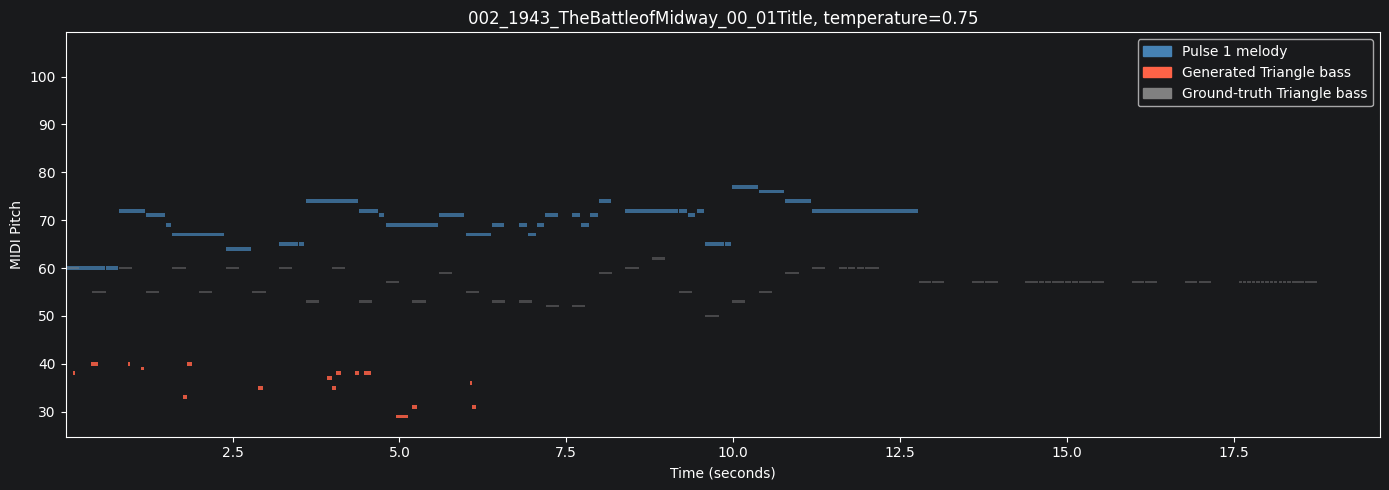

Saved figure: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p75.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid temp= 0.75 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p85.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Generated tokens: 160
Generated notes: 22


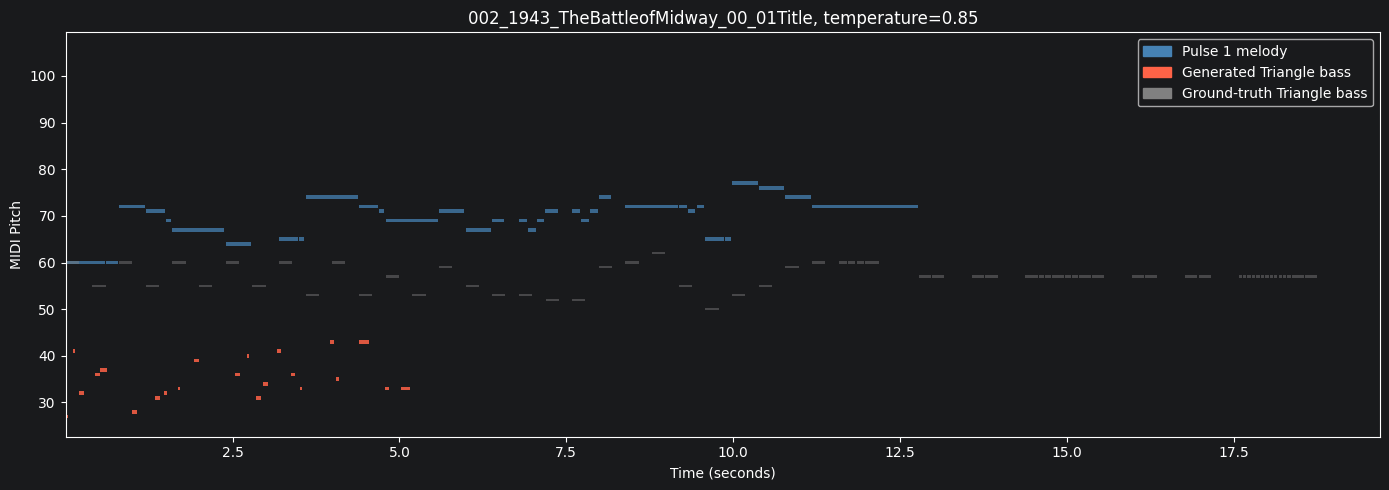

Saved figure: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p85.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid temp= 0.85 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p95.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Generated tokens: 118
Generated notes: 23


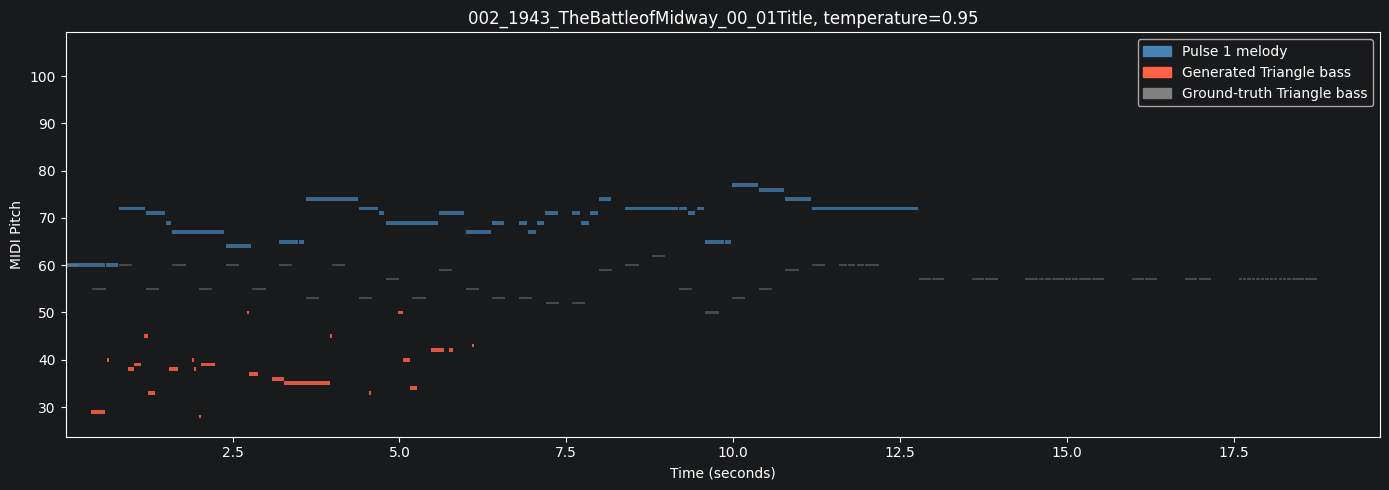

Saved figure: generated_candidates\candidate_0_002_1943_TheBattleofMidway_00_01Title_temp0p95.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid temp= 0.95 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p75.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid
Generated tokens: 160
Generated notes: 16


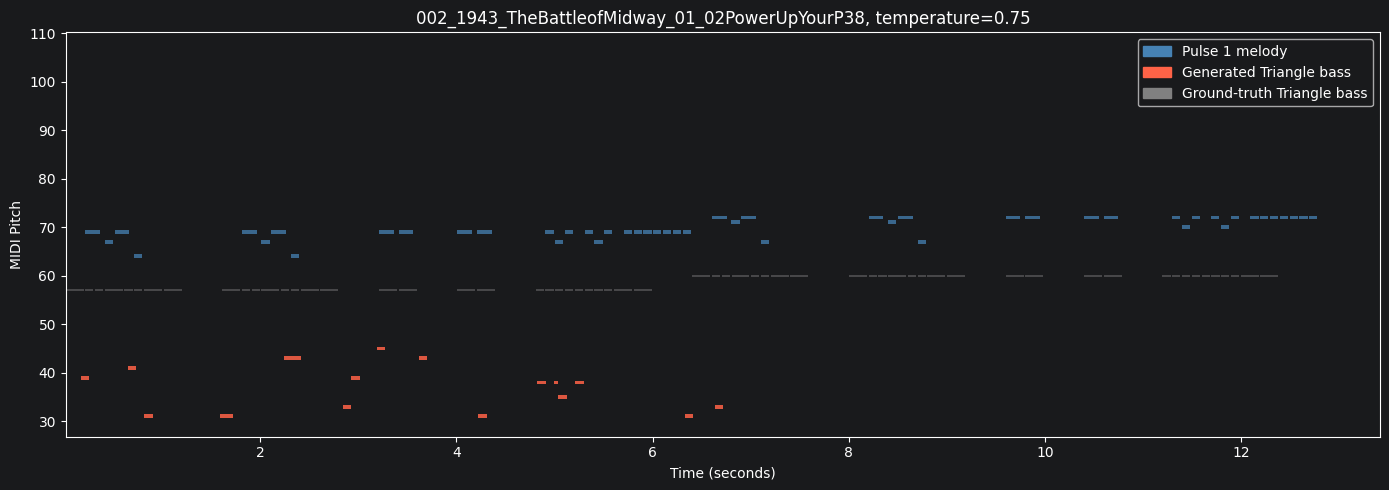

Saved figure: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p75.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid temp= 0.75 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p85.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid
Generated tokens: 160
Generated notes: 19


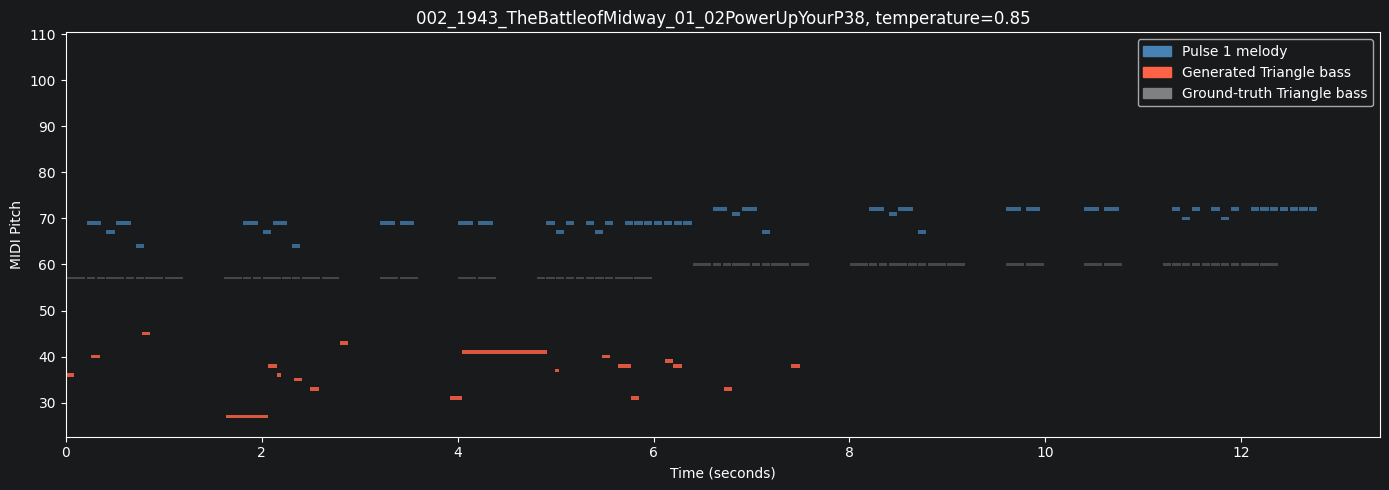

Saved figure: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p85.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid temp= 0.85 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p95.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid
Generated tokens: 160
Generated notes: 21


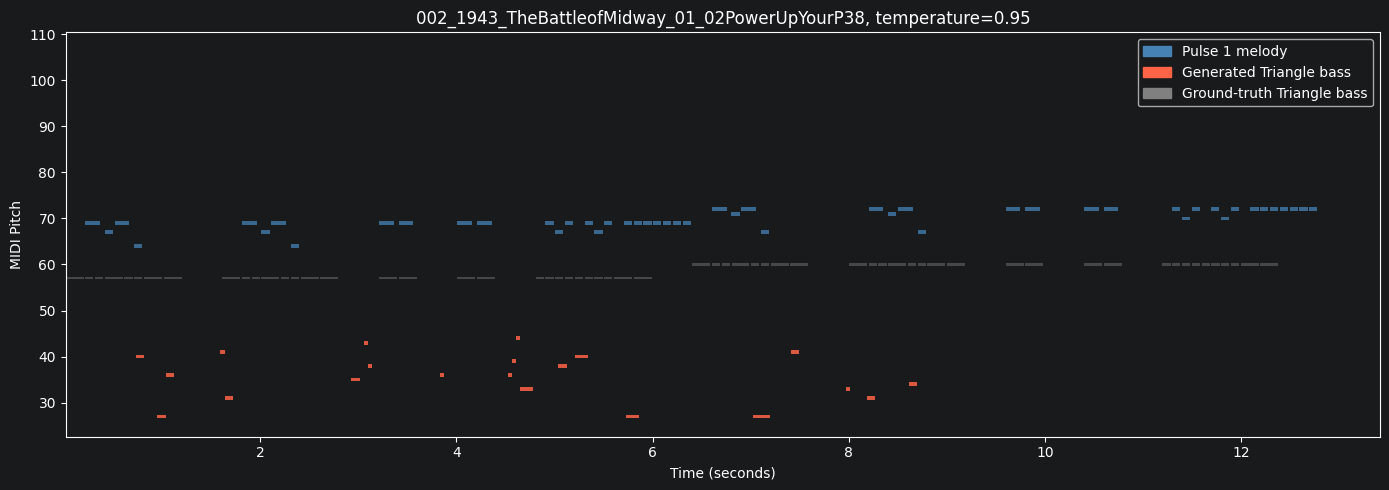

Saved figure: generated_candidates\candidate_1_002_1943_TheBattleofMidway_01_02PowerUpYourP38_temp0p95.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_01_02PowerUpYourP38.mid temp= 0.95 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p75.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid
Generated tokens: 160
Generated notes: 14


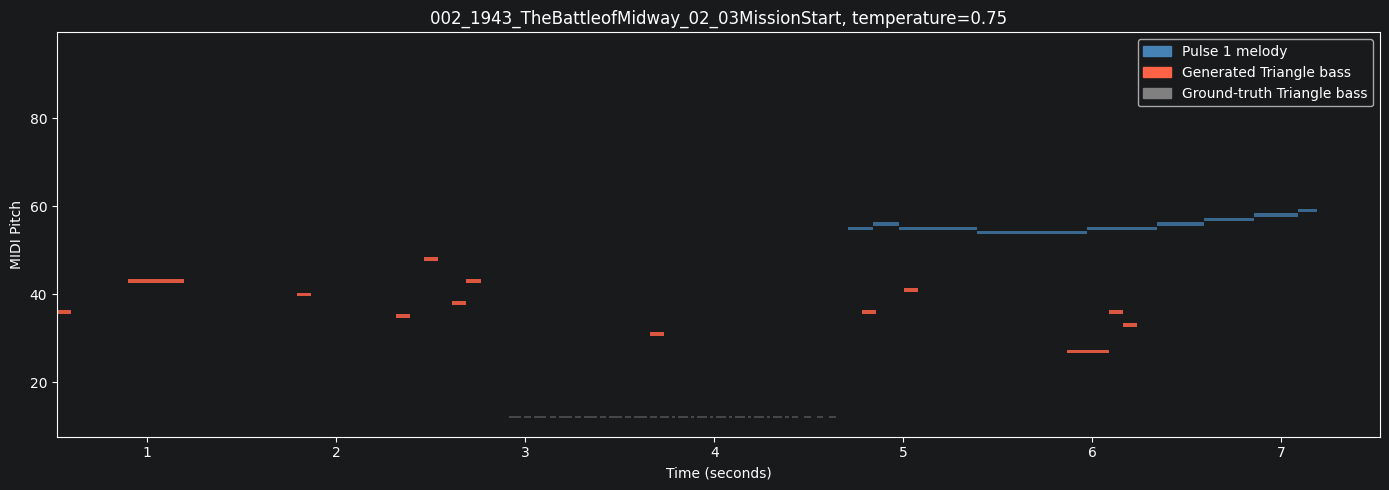

Saved figure: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p75.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid temp= 0.75 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p85.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid
Generated tokens: 160
Generated notes: 27


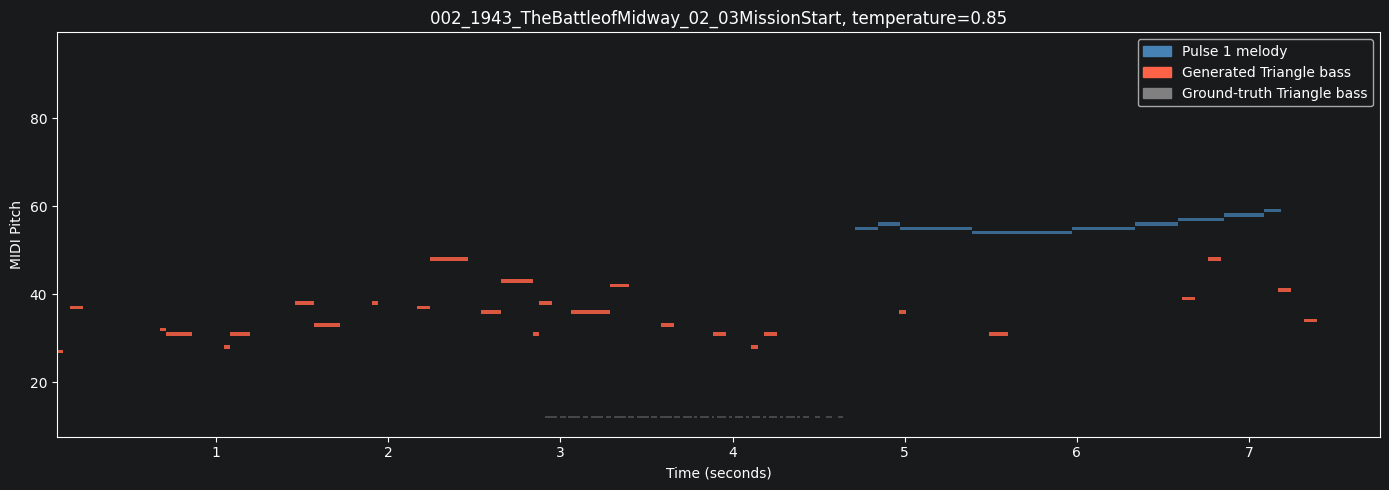

Saved figure: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p85.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid temp= 0.85 error= name 'summarize_generation' is not defined
Saved: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p95.mid
Source: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid
Generated tokens: 160
Generated notes: 26


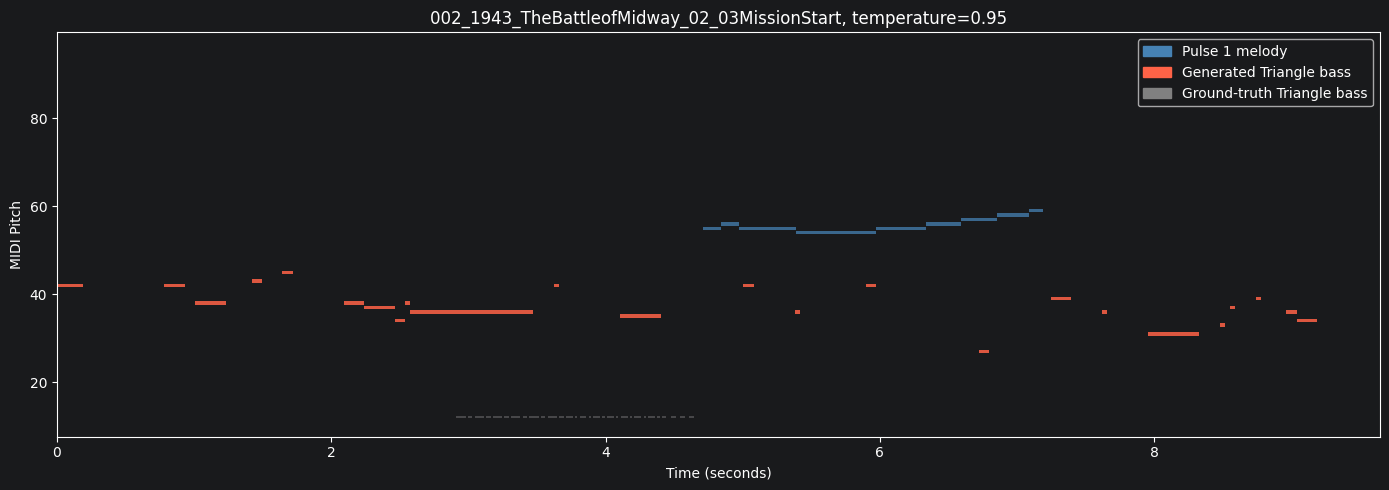

Saved figure: generated_candidates\candidate_2_002_1943_TheBattleofMidway_02_03MissionStart_temp0p95.png
Failed: nesmdb_midi\test\002_1943_TheBattleofMidway_02_03MissionStart.mid temp= 0.95 error= name 'summarize_generation' is not defined


""


In [27]:
def generate_multiple_candidates(
    model,
    midi_files,
    output_dir="generated_candidates",
    n_files=5,
    temperatures=(0.75, 0.85, 0.95),
    top_k=20,
):
    os.makedirs(output_dir, exist_ok=True)

    results = []

    selected_files = midi_files[:n_files]

    for file_idx, midi_path in enumerate(selected_files):
        for temp in temperatures:
            base = Path(midi_path).stem
            safe_temp = str(temp).replace(".", "p")

            out_path = os.path.join(
                output_dir,
                f"candidate_{file_idx}_{base}_temp{safe_temp}.mid"
            )

            fig_path = os.path.join(
                output_dir,
                f"candidate_{file_idx}_{base}_temp{safe_temp}.png"
            )

            try:
                result = save_conditioned_generation(
                    model,
                    midi_path,
                    output_path=out_path,
                    temperature=temp,
                    top_k=top_k,
                    max_p1=192,
                    max_gen_len=160,
                    include_ground_truth=False,
                )

                plot_piano_roll(
                    result["p1"],
                    result["generated_tr"],
                    ground_truth_tr_inst=result["ground_truth_tr"],
                    title=f"{base}, temperature={temp}",
                    output_path=fig_path,
                )

                metrics = summarize_generation(
                    result["p1"],
                    result["generated_tr"],
                    result["ground_truth_tr"],
                )

                gen_row = metrics.loc[metrics["track"] == "Generated TR bass"].iloc[0]

                results.append({
                    "midi_path": midi_path,
                    "output_path": out_path,
                    "figure_path": fig_path,
                    "temperature": temp,
                    "generated_notes": len(result["generated_tr"].notes),
                    "pc_compatibility": float(gen_row["pc_compatibility_with_p1"]),
                    "onset_alignment": float(gen_row["onset_alignment_with_p1"]),
                })

            except Exception as e:
                print("Failed:", midi_path, "temp=", temp, "error=", e)

    df = pd.DataFrame(results)
    if len(df) > 0:
        df.to_csv(os.path.join(output_dir, "candidate_summary.csv"), index=False)

    return df


candidate_df = generate_multiple_candidates(
    model,
    test_files if len(test_files) > 0 else valid_files,
    output_dir="generated_candidates",
    n_files=3,
    temperatures=(0.75, 0.85, 0.95),
    top_k=20,
)

display(candidate_df)

In [28]:
# Choose one candidate as the final file.
# By default, choose the first candidate. We can manually change this after listening.
if len(candidate_df) > 0:
    chosen_candidate = candidate_df.iloc[0]["output_path"]
    shutil.copy(chosen_candidate, "symbolic_conditioned.mid")
    print("Final symbolic_conditioned.mid copied from:", chosen_candidate)
else:
    print("No candidates generated. Keeping the earlier symbolic_conditioned.mid file.")

No candidates generated. Keeping the earlier symbolic_conditioned.mid file.


In [29]:
def save_versions_for_midi(
    model,
    midi_path,
    output_dir="demo_outputs",
    base_name=None,
    temperature=0.75,
    top_k=20,
    max_p1=192,
    max_gen_len=300,
    min_events_before_eos=40,
    generated_program=38,
    generated_velocity=100,
    generated_transpose=0,
):
    """
    Given one NES-MDB MIDI file, save:
      1. no bass version: P1 melody only
      2. bass only version: ground-truth TR only
      3. generated-with-bass version: P1 melody + generated TR bass
      4. original-with-truth version: P1 melody + ground-truth TR bass
    """
    os.makedirs(output_dir, exist_ok=True)

    pm, p1, tr, tempo = load_nes_tracks(midi_path)

    if p1 is None or tr is None:
        raise ValueError(f"Could not load P1/TR from {midi_path}")

    if base_name is None:
        base_name = Path(midi_path).stem

    # Make copies so we do not mutate the original objects.
    p1_copy = copy.deepcopy(p1)
    p1_copy.name = "Pulse 1 Melody"
    p1_copy.program = 80  # Lead 1 square-ish in General MIDI

    tr_truth = copy.deepcopy(tr)
    tr_truth.name = "Ground Truth Triangle Bass"
    tr_truth.program = 38  # Synth Bass 1, easier to hear than default

    # -----------------------------
    # 1. No bass: P1 melody only
    # -----------------------------
    no_bass_pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    no_bass_pm.instruments.append(copy.deepcopy(p1_copy))

    no_bass_path = os.path.join(output_dir, f"{base_name}_no_bass.mid")
    no_bass_pm.write(no_bass_path)

    # -----------------------------
    # 2. Bass only: original TR only
    # -----------------------------
    bass_only_pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    bass_only_pm.instruments.append(copy.deepcopy(tr_truth))

    bass_only_path = os.path.join(output_dir, f"{base_name}_truth_bass_only.mid")
    bass_only_pm.write(bass_only_path)

    # -----------------------------
    # 3. Generate bass from P1
    # -----------------------------
    raw_p1_tokens = track_to_tokens(p1, tempo, add_rests=True)
    p1_tokens = [BOS] + raw_p1_tokens[:max_p1] + [EOS]

    generated_tokens = generate_bass(
        model,
        p1_tokens,
        temperature=temperature,
        top_k=top_k,
        max_len=max_gen_len,
        min_events_before_eos=min_events_before_eos,
    )

    generated_tr = tokens_to_midi_track(
        generated_tokens,
        tempo=tempo,
        program=generated_program,
        velocity=generated_velocity,
        transpose=generated_transpose,
        name="Generated Triangle Bass",
    )

    generated_with_bass_pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    generated_with_bass_pm.instruments.append(copy.deepcopy(p1_copy))
    generated_with_bass_pm.instruments.append(copy.deepcopy(generated_tr))

    generated_with_bass_path = os.path.join(output_dir, f"{base_name}_generated_with_bass.mid")
    generated_with_bass_pm.write(generated_with_bass_path)

    # -----------------------------
    # 4. Original comparison: P1 + ground-truth TR
    # -----------------------------
    truth_with_bass_pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    truth_with_bass_pm.instruments.append(copy.deepcopy(p1_copy))
    truth_with_bass_pm.instruments.append(copy.deepcopy(tr_truth))

    truth_with_bass_path = os.path.join(output_dir, f"{base_name}_truth_with_bass.mid")
    truth_with_bass_pm.write(truth_with_bass_path)

    print("Saved demo files:")
    print("No bass:             ", no_bass_path)
    print("Truth bass only:     ", bass_only_path)
    print("Generated with bass: ", generated_with_bass_path)
    print("Truth with bass:     ", truth_with_bass_path)

    print()
    print("Source MIDI:", midi_path)
    print("Tempo:", tempo)
    print("Raw P1 tokens:", len(raw_p1_tokens))
    print("Used P1 tokens:", min(len(raw_p1_tokens), max_p1))
    print("Generated tokens:", len(generated_tokens))
    print("Generated notes:", len(generated_tr.notes))
    print("Ground-truth TR notes:", len(tr_truth.notes))

    return {
        "source_midi": midi_path,
        "tempo": tempo,
        "no_bass_path": no_bass_path,
        "bass_only_path": bass_only_path,
        "generated_with_bass_path": generated_with_bass_path,
        "truth_with_bass_path": truth_with_bass_path,
        "p1": p1_copy,
        "truth_tr": tr_truth,
        "generated_tr": generated_tr,
        "generated_tokens": generated_tokens,
    }

In [30]:
chosen_midi = test_files[0]

demo = save_versions_for_midi(
    model,
    chosen_midi,
    output_dir="demo_outputs",
    temperature=0.75,
    top_k=20,
    max_p1=192,
    max_gen_len=300,
    min_events_before_eos=40,
    generated_transpose=0,
)

Saved demo files:
No bass:              demo_outputs\002_1943_TheBattleofMidway_00_01Title_no_bass.mid
Truth bass only:      demo_outputs\002_1943_TheBattleofMidway_00_01Title_truth_bass_only.mid
Generated with bass:  demo_outputs\002_1943_TheBattleofMidway_00_01Title_generated_with_bass.mid
Truth with bass:      demo_outputs\002_1943_TheBattleofMidway_00_01Title_truth_with_bass.mid

Source MIDI: nesmdb_midi\test\002_1943_TheBattleofMidway_00_01Title.mid
Tempo: 218.1534519717399
Raw P1 tokens: 94
Used P1 tokens: 94
Generated tokens: 300
Generated notes: 30
Ground-truth TR notes: 74


In [ ]:
import shutil, pathlib

_src  = pathlib.Path("symbolic_conditioned.mid")
_dst  = pathlib.Path("../outputs/symbolic_conditioned.mid")
_dst.parent.mkdir(parents=True, exist_ok=True)

if _src.exists():
    shutil.copy(_src, _dst)
    print("Copied to:", _dst.resolve())
else:
    print("symbolic_conditioned.mid not found in Task2/ — run generation cell first.")
